# Check input data shape

In [87]:
import rasterio
from glob import glob
images = glob(r'D:\Personal Projects\CNN\field_boundary_delineation\data\raster\images\*.tif')
uq = []
for file in images:
    with rasterio.open(file) as src:
        print(src.shape)
        uq.append(src.shape)

# create raster mask from vector data

In [90]:
import rasterio
import geopandas as gpd
import shapely.geometry
from rasterio.features import rasterize
from rasterio.transform import from_origin
import os
from glob import glob
from tqdm import tqdm

MAIN_DIR = os.path.dirname(os.getcwd())

# File paths
polygon_paths = glob(os.path.join(MAIN_DIR, 'data/vector/AI4smallFarms_complete_Datasets/sentinel-2-asia/reference/*_lines.gpkg'))
raster_path = os.path.join(MAIN_DIR, 'data/raster/images')
out_mask_dir = os.path.join(MAIN_DIR, 'data/raster/mask')
os.makedirs(out_mask_dir, exist_ok=True)

for polygon_path in tqdm(polygon_paths):
    farm_gdf = gpd.read_file(polygon_path)
    raster_base_name = f"{os.path.basename(polygon_path).split('_lines')[0]}.tif"
    raster_file_name = os.path.join(raster_path, raster_base_name)
    # it creates generator of polygon and values pair
    shapes = ((geom, 1) for geom in farm_gdf.geometry)
    with rasterio.open(raster_file_name) as src:
        mask_profile = src.profile.copy()
        mask_profile.update({'count':1, 'dtype':'uint8'})

        mask = rasterize(shapes=shapes, out_shape=(src.height, src.width),
                        transform=src.transform,
                        fill=0,
                        default_value=1,
                        dtype='uint8'
                        )
    out_mask_path = os.path.join(out_mask_dir, raster_base_name)
    with rasterio.open(out_mask_path, 'w', **mask_profile) as dst:
        dst.write(mask, 1)
print('All masked are generated')

100%|██████████| 62/62 [00:36<00:00,  1.68it/s]

All masked are generated


# Split mask and image into fixed tile size with overlap

In [91]:
import rasterio
import os
from glob import glob
from rasterio.windows import Window
from affine import Affine
from tqdm import tqdm

MAIN_DIR = os.path.dirname(os.getcwd())

tile_size = 512
stride = 128
raster_paths = glob(os.path.join(MAIN_DIR, 'data/raster/images/*.tif'))
mask_path = os.path.join(MAIN_DIR, 'data/raster/masks')
tile_mask_dir = os.path.join(MAIN_DIR, 'data/raster/tiles/masks')
tile_image_dir = os.path.join(MAIN_DIR, 'data/raster/tiles/images')
os.makedirs(tile_mask_dir, exist_ok=True)
os.makedirs(tile_image_dir, exist_ok=True)
idx = 0
for raster_path in tqdm(raster_paths):
    tif_base_name = os.path.basename(raster_path)
    mask_path = os.path.join(MAIN_DIR, f'data/raster/mask/{tif_base_name}')
    with rasterio.open(raster_path) as img_src, rasterio.open(mask_path) as mask_src:
        # print(mask_src.transform==img_src.transform)
        # print(mask_src.shape==img_src.shape)
        # print(img_src.transform.almost_equals(mask_src.transform))
        full_window = Window(0, 0, img_src.width, img_src.height)
        if mask_src.transform==img_src.transform and mask_src.shape==img_src.shape:
            for row in range(0, img_src.height + 1, stride):
                for col in range(0, img_src.width + 1, stride):
                    col = min(col, img_src.width - tile_size)
                    row = min(row, img_src.height - tile_size)
                    window = Window(
                                col,
                                row,
                                min(tile_size, img_src.width-col),
                                min(tile_size, img_src.height-row)
                            )
                    window = window.intersection(full_window)
                    if window.width != tile_size or window.height != tile_size:
                        continue
                    
                    image_file = os.path.join(os.path.join(tile_image_dir, f'{tif_base_name.split('.')[0]}_{idx}.tif'))
                    mask_file = os.path.join(os.path.join(tile_mask_dir, f'{tif_base_name.split('.')[0]}_{idx}.tif'))
                    idx +=1
                    new_transform = img_src.window_transform(window)
                    image_profile = img_src.profile.copy()
                    image_profile.update({
                                "height": int(window.height),
                                "width": int(window.width),
                                "transform": new_transform
                    })
                    mask_profile = mask_src.profile.copy()
                    mask_profile.update({
                                "height": int(window.height),
                                "width": int(window.width),
                                "transform": new_transform
                    })
                    img = img_src.read(window=window)
                    mask = mask_src.read(window=window)
                    with rasterio.open(image_file, 'w', **image_profile) as img_dst, rasterio.open(mask_file, 'w', **mask_profile) as mask_dst:
                        img_dst.write(img)
                        mask_dst.write(mask)
print('Image and mask are splited into fixed size')


100%|██████████| 62/62 [01:18<00:00,  1.26s/it]

Image and mask are splited into fixed size


# Random visualization of image + mask pairs

C:\Users\HP\AppData\Local\Temp\ipykernel_2904\2916995412.py:18: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mask = m_src.read(1)


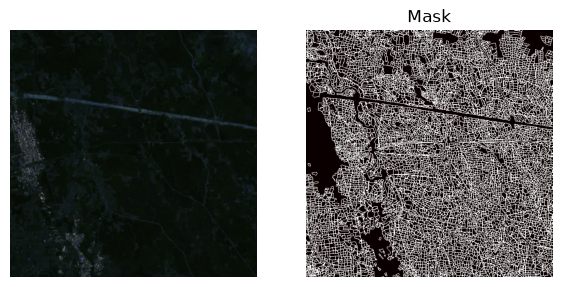

In [92]:
import matplotlib.pyplot as plt
import rasterio
import random
import numpy as np


MAIN_DIR = os.path.dirname(os.getcwd())
tile_mask_dir = os.path.join(MAIN_DIR, 'data/raster/tiles/masks')
tile_image_dir = os.path.join(MAIN_DIR, 'data/raster/tiles/images')

def pick_image_and_mask(image_dir, mask_dir, indx = 1):
    img_path = glob(os.path.join(image_dir, '*.tif'))[indx]
    mask_path = glob(os.path.join(mask_dir, '*.tif'))[indx]
    with rasterio.open(img_path) as src:
        image = src.read([1, 2, 3])/10000
        image = np.moveaxis(image, 0, -1)
    with rasterio.open(mask_path) as m_src:
        mask = m_src.read(1)
    return image, mask
def plot_sample(image, mask):
    extent = (0, 25, 0, 25)

    fig, ax = plt.subplot_mosaic([
        ['image', 'mask']
    ], figsize=(7, 3.5))

    ax['image'].imshow(image)
    ax['image'].axis('off')  # clear x-axis and y-axis

    im = ax['mask'].imshow(mask, cmap="hot", origin='upper', extent=extent)

    ax['mask'].set_title('Mask')
    ax['mask'].axis('off')

    plt.show()
imge, mask = pick_image_and_mask(tile_image_dir, tile_mask_dir, 200)
plot_sample(imge, mask)

# check percentage of farm precent in each tiles

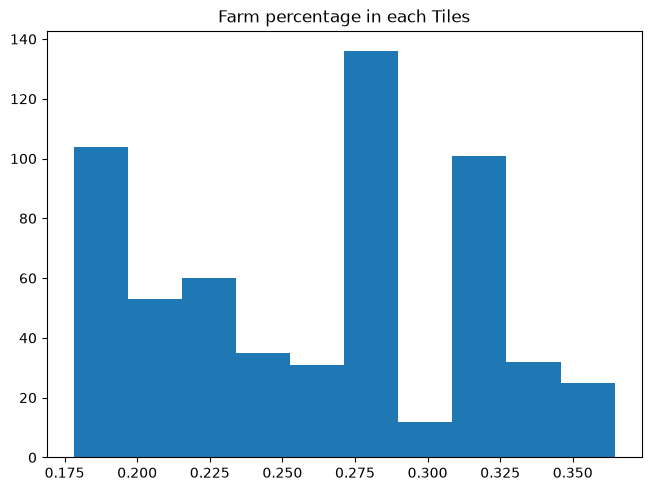

In [93]:
import rasterio
import os
from glob import glob
import matplotlib.pyplot as plt

MAIN_DIR = os.path.dirname(os.getcwd())
tile_mask_files = glob(os.path.join(MAIN_DIR, 'data/raster/tiles/masks/*.tif'))
percentage_list = []
for file in tile_mask_files:
    with rasterio.open(file) as mask_src:
        mask = mask_src.read()
        percentage_list.append((mask==1).sum()/mask.size)


fig, ax = plt.subplots(layout='constrained')
ax.hist(percentage_list, 10)
ax.set_title('Farm percentage in each Tiles')

plt.show()

We can observ that most of the tiles contain farm land there is very few outliers, so we can say the data is balance

# Train / Validation / Test split | Split geographically.

In [94]:
import os
import random
import shutil
from glob import glob


# ============================================================
# Configuration
# ============================================================

MAIN_DIR = os.path.dirname(os.getcwd())

FULL_IMAGE_DIR = os.path.join(MAIN_DIR, "data", "raster", "images")
TILE_IMAGE_DIR = os.path.join(MAIN_DIR, "data", "raster", "tiles", "images")
MASK_DIR = os.path.join(MAIN_DIR, "data", "raster", "tiles", "masks")

TRAIN_IMAGE_DIR = os.path.join(MAIN_DIR, "data", "train", "images")
TRAIN_MASK_DIR = os.path.join(MAIN_DIR, "data", "train", "masks")

VAL_IMAGE_DIR = os.path.join(MAIN_DIR, "data", "val", "images")
VAL_MASK_DIR = os.path.join(MAIN_DIR, "data", "val", "masks")

TEST_IMAGE_DIR = os.path.join(MAIN_DIR, "data", "test", "images")
TEST_MASK_DIR = os.path.join(MAIN_DIR, "data", "test", "masks")

VAL_SPLIT = 0.20
TEST_SPLIT = 0.20
RANDOM_SEED = 42


# ============================================================
# Create output directories
# ============================================================

for directory in [
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR,
    VAL_IMAGE_DIR,
    VAL_MASK_DIR,
    TEST_IMAGE_DIR,
    TEST_MASK_DIR,
]:
    os.makedirs(directory, exist_ok=True)


# ============================================================
# Get full image IDs
# ============================================================

raster_full_image_files = glob(
    os.path.join(FULL_IMAGE_DIR, "*.tif")
)

if not raster_full_image_files:
    raise RuntimeError(
        f"No full raster images found in: {FULL_IMAGE_DIR}"
    )


# Example filename:
# 123_something.tif
# -> ID = 123

image_ids = sorted(
    {
        int(os.path.basename(path).split("_")[0])
        for path in raster_full_image_files
    }
)

n = len(image_ids)

if n == 0:
    raise RuntimeError("No image IDs found.")


# ============================================================
# Shuffle IDs and split
# ============================================================

random.seed(RANDOM_SEED)
random.shuffle(image_ids)

n_val = int(n * VAL_SPLIT)
n_test = int(n * TEST_SPLIT)

val_ids = set(image_ids[:n_val])

test_ids = set(
    image_ids[n_val:n_val + n_test]
)

train_ids = set(
    image_ids[n_val + n_test:]
)


# ============================================================
# Print split information
# ============================================================

print(f"Total source images : {n}")
print(f"Train source images : {len(train_ids)}")
print(f"Val source images   : {len(val_ids)}")
print(f"Test source images  : {len(test_ids)}")

print()
print(f"Train IDs: {sorted(train_ids)}")
print(f"Val IDs  : {sorted(val_ids)}")
print(f"Test IDs : {sorted(test_ids)}")


# ============================================================
# Get tiled images
# ============================================================

raster_tile_image_files = glob(
    os.path.join(TILE_IMAGE_DIR, "*.tif")
)

if not raster_tile_image_files:
    raise RuntimeError(
        f"No tile images found in: {TILE_IMAGE_DIR}"
    )


# ============================================================
# Copy images and masks
# ============================================================

train_count = 0
val_count = 0
test_count = 0
missing_mask_count = 0
unknown_id_count = 0

for raster_path in raster_tile_image_files:

    filename = os.path.basename(raster_path)

    try:
        source_id = int(filename.split("_")[0])
    except ValueError:
        print(f"Skipping file with invalid ID: {filename}")
        continue

    mask_path = os.path.join(MASK_DIR, filename)

    # --------------------------------------------------------
    # Check mask exists
    # --------------------------------------------------------

    if not os.path.exists(mask_path):
        print(f"WARNING: Mask not found for {filename}")
        missing_mask_count += 1
        continue

    # --------------------------------------------------------
    # Decide split
    # --------------------------------------------------------

    if source_id in train_ids:

        image_out = os.path.join(
            TRAIN_IMAGE_DIR,
            filename
        )

        mask_out = os.path.join(
            TRAIN_MASK_DIR,
            filename
        )

        train_count += 1

    elif source_id in val_ids:

        image_out = os.path.join(
            VAL_IMAGE_DIR,
            filename
        )

        mask_out = os.path.join(
            VAL_MASK_DIR,
            filename
        )

        val_count += 1

    elif source_id in test_ids:

        image_out = os.path.join(
            TEST_IMAGE_DIR,
            filename
        )

        mask_out = os.path.join(
            TEST_MASK_DIR,
            filename
        )

        test_count += 1

    else:
        print(
            f"WARNING: ID {source_id} not found in any split: "
            f"{filename}"
        )
        unknown_id_count += 1
        continue

    # --------------------------------------------------------
    # Copy image and mask
    # --------------------------------------------------------

    shutil.copy2(raster_path, image_out)
    shutil.copy2(mask_path, mask_out)


# ============================================================
# Final summary
# ============================================================

print("\n========================================")
print("Dataset split completed")
print("========================================")

print(f"Train tiles : {train_count}")
print(f"Val tiles   : {val_count}")
print(f"Test tiles  : {test_count}")

print(f"Missing masks : {missing_mask_count}")
print(f"Unknown IDs   : {unknown_id_count}")

Total source images : 62
Train source images : 38
Val source images   : 12
Test source images  : 12

Train IDs: [0, 1, 2, 5, 6, 7, 8, 12, 13, 14, 15, 17, 22, 24, 25, 26, 27, 28, 30, 32, 34, 35, 37, 38, 40, 41, 43, 44, 46, 47, 48, 49, 51, 53, 55, 57, 58, 59]
Val IDs  : [9, 11, 16, 18, 19, 20, 21, 31, 33, 56, 60, 61]
Test IDs : [3, 4, 10, 23, 29, 36, 39, 42, 45, 50, 52, 54]

Dataset split completed
Train tiles : 373
Val tiles   : 116
Test tiles  : 100
Missing masks : 0
Unknown IDs   : 0


In [85]:
a = [5,8,9,10]
a.reverse()

In [95]:
import matplotlib.pyplot as plt

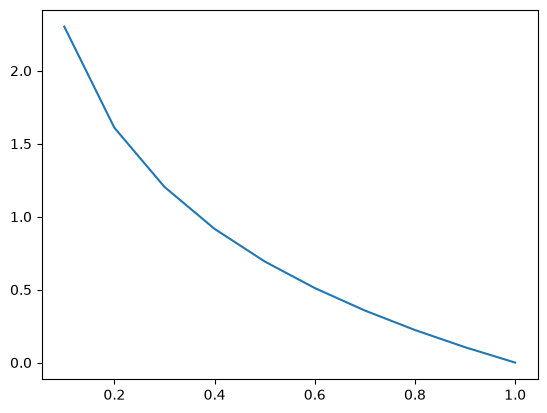

In [118]:
n = np.array(list(range(10,0,-1)))/10
l = -np.log(n)
plt.plot(n,l)

In [130]:
array1 = np.array([1,1,1,0])
array1_bool = array1.astype(bool)
array2 = np.array([1,0,1,0])
array2_bool = array2.astype(bool)
_union = array1_bool+array2_bool
_intersection = array1_bool*array2_bool
_union

array([ True,  True,  True, False])

In [141]:
import tensorflow as tf 

mask = tf.convert_to_tensor([[1,1,1,0]], dtype=tf.float16)
pred = tf.convert_to_tensor([[0.9,0.2,0.85,0.1]], dtype=tf.float16)
soft_intersection = tf.reduce_sum(mask*pred)
sum_gt = tf.reduce_sum(mask)
sum_pred = tf.reduce_sum(pred)
dice_cof = (2*soft_intersection)/(sum_gt+sum_pred)
dice_cof

<tf.Tensor: shape=(), dtype=float16, numpy=0.7724609375>

In [156]:
x = np.array([[[[1],[1]],[[0],[0]]]])
print(x)
print(x.shape)

[[[[1]
   [1]]

  [[0]
   [0]]]]
(1, 2, 2, 1)


In [174]:
import os
from glob import glob

folder = glob(r'D:/Satyukt/Projects/CROPIC/Crop_stage_data/*')

for crop in folder:

    image_name_root = os.path.basename(crop).replace(' ', '_')

    # Get only files, not folders
    list_crop = [
        f for f in glob(os.path.join(crop, '*'))
        if os.path.isfile(f)
    ]

    counter = 1

    for file in list_crop:

        filename = os.path.basename(file)
        name, ext = os.path.splitext(filename)

        # Skip files that are already renamed
        if name.startswith(image_name_root + "_"):
            continue

        # Find an available filename
        while True:

            new_name = os.path.join(
                crop,
                f"{image_name_root}_{counter}{ext}"
            )

            if not os.path.exists(new_name):
                break

            counter += 1

        try:
            os.rename(file, new_name)
            print(f"{filename}  -->  {os.path.basename(new_name)}")

        except FileNotFoundError:
            print(f"SKIPPED (file no longer exists): {file}")

        counter += 1

print("completed")

close-up-vibrant-green-rice-plants-ripening-yellow-grains-lush-paddy-field-397138253_jpg.rf.200d95f624d567f1456e42ebb94384b3.jpg  -->  Paddy_Grain_Ripening_Phase_18.jpg
close-up-view-of-lowland-rice-plants-with-detailed-texture-and-natural-light-photo_jpg.rf.1a9e67830889a6c8c598b8b2efce317c.jpg  -->  Paddy_Grain_Ripening_Phase_19.jpg
close-up-yellow-green-rice-field-view-paddy-field_503026-242_jpg.rf.9a5ae474ab05a73e285f5f902d269676.jpg  -->  Paddy_Grain_Ripening_Phase_20.jpg
close-up-young-green-paddy-rice-ear-fertile-field-detailed-vertical-close-up-young-rice-stalk-oryza-sativa-436828611_jpg.rf.422444d0c5fef03630b263d9c5afab31.jpg  -->  Paddy_Grain_Ripening_Phase_21.jpg
closeup-lush-green-rice-field-260nw-2624058843_jpg.rf.7633ae142766bf425fc3f46ba3fb83a4.jpg  -->  Paddy_Grain_Ripening_Phase_22.jpg
closeup-rice-panicles-swaying-gently-260nw-2718131009_jpg.rf.69ac292e810317215bfeee3c3376d9e7.jpg  -->  Paddy_Grain_Ripening_Phase_23.jpg
closeup-rice-plant-field-ready-260nw-2668846053_j

In [167]:
glob(os.path.join(crop, '*'))

['D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\Chickpea_99812_2_02122024.jpg',
 'D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\cropped_IMG_1830_JPG.rf.b2e7104b6c24f9633f781eb044ff00e7.jpg',
 'D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\cropped_IMG_1834_JPG.rf.613fe4140d734c870129ac9421928a52.jpg',
 'D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\cropped_IMG_1835_JPG.rf.b02e662deeeab93b411b338224be043f.jpg',
 'D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\cropped_IMG_1837_JPG.rf.c65e8474fbb86632576606eadaa83f51.jpg',
 'D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\cropped_IMG_1840_JPG.rf.a0ccdcfde3043cee82e32d85f2e3b004.jpg',
 'D:/Satyukt/Projects/CROPIC/Crop_stage_data\\Bengal Gram Early Vegetative Stage\\cropped_IMG_1842_JPG.rf.3fce9968270eec36477e06fff14b4403.jpg',
 'D:/Satyukt/Pro